# INFO_S* — Information Sources (Stacked Bar)
Shows for each INFO_S field how respondents rated the information source.
Values: 0=not used, 1=used/no influence, 2=used/led to action, 3=used/led to inaction.
None values are excluded.

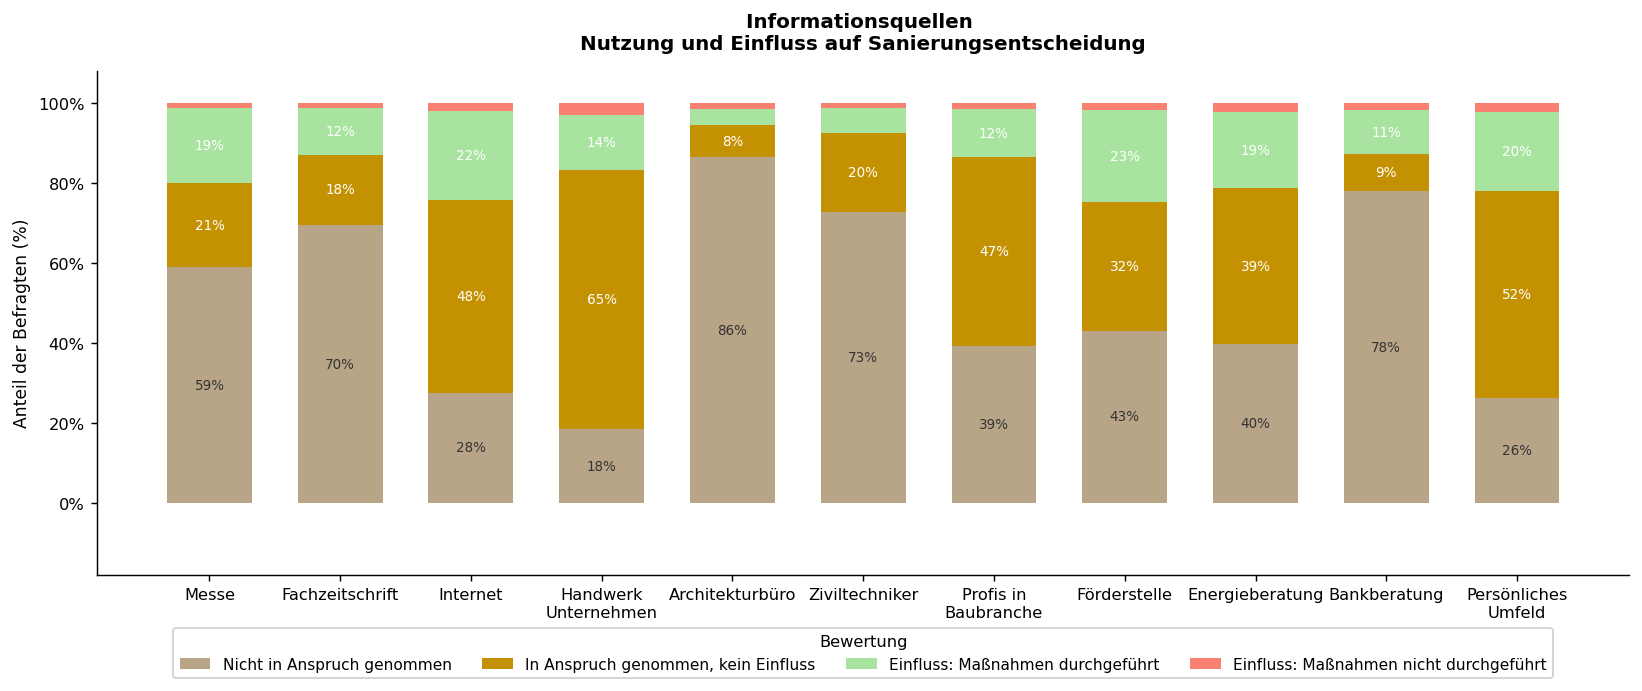

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Load ──────────────────────────────────────────────────────────────────────
with open("../data/processed/survey_v1.1.json") as f:
    data = json.load(f)

FIELDS = [f"INFO_S{i}" for i in range(1, 12)]

# ── Edit these comments — one per field (INFO_S1 … INFO_S12) ─────────────────
COMMENTS = []

# ── Edit these tick labels — one per field ────────────────────────────────────
TICK_LABELS = [
    "Messe",   # INFO_S1
    "Fachzeitschrift",            # INFO_S2
    "Internet",          # INFO_S3
    "Handwerk\nUnternehmen",           # INFO_S4
    "Architekturbüro",        # INFO_S5
    "Ziviltechniker",         # INFO_S6
    "Profis in\nBaubranche",    # INFO_S7
    "Förderstelle",          # INFO_S8
    "Energieberatung",             # INFO_S9
    "Bankberatung",          # INFO_S10
    "Persönliches\nUmfeld",           # INFO_S11
]


VALS   = ["0", "1", "2", "3"]
LABELS = [
    "Nicht in Anspruch genommen",
    "In Anspruch genommen, kein Einfluss",
    "Einfluss: Maßnahmen durchgeführt",
    "Einfluss: Maßnahmen nicht durchgeführt",
]
COLORS = ["#B8A487", "#C49102", "#A8E4A0", "#FA8072"]

# ── Count per field (skip None) ───────────────────────────────────────────────
counts = {}
totals = {}
for field in FIELDS:
    grp = [r for r in data if str(r.get(field, "None")) in VALS]
    counts[field] = [sum(1 for r in grp if str(r[field]) == v) for v in VALS]
    totals[field] = len(grp)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":       130,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
    "axes.labelsize":   9.5,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
})

fig, ax = plt.subplots(figsize=(13, 5.5))
x      = np.arange(len(FIELDS))
bottom = np.zeros(len(FIELDS))

for vi, (val, lbl, col) in enumerate(zip(VALS, LABELS, COLORS)):
    heights = [counts[f][vi] / totals[f] * 100 for f in FIELDS]
    bars    = ax.bar(x, heights, bottom=bottom, color=col, width=0.65, label=lbl)
    for xi, (h, b) in enumerate(zip(heights, bottom)):
        if h >= 7:
            ax.text(xi, b + h / 2, f"{h:.0f}%",
                    ha="center", va="center", fontsize=7.5,
                    color="white" if vi in (1, 2, 3) else "#333")
    bottom += np.array(heights)

# n= and comment annotations below x-axis
for xi, (f, comment) in enumerate(zip(FIELDS, COMMENTS)):
    ax.text(xi, -4,  f"n={totals[f]}", ha="center", va="top", fontsize=7.5, color="#666")
    ax.text(xi, -10, comment,          ha="center", va="top", fontsize=7.5, color="#333",
            style="italic", wrap=True)

ax.set_xticks(x)
# ax.set_xticklabels(FIELDS, fontsize=9)
ax.set_xticklabels(TICK_LABELS, fontsize=9)
ax.set_ylabel("Anteil der Befragten (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(-18, 108)
ax.set_title("Informationsquellen \nNutzung und Einfluss auf Sanierungsentscheidung", pad=12)

ax.legend(
    title="Bewertung",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=4,
    fontsize=8.5,
    title_fontsize=9,
    framealpha=0.9,
)

plt.tight_layout()
plt.show()